Predictions: [0 0 1 0 0 0 0 1 0 1 0 0 1 1 1 0 0 1 1 1 0 1 0 1 1 1 1 0 0 0 0 0 1 0 0 0 1
 1 0 0 1 1 1 1 0 1 0 0 0 0 1 1 0 0 0 1 0 1 1 0 1 1 1 1 0 1 1 1 0 0 1 0 1 0
 0 1 0 1 1 0 1 0 1 0 1 0 0 0 1 1 1 0 0 1 1 0 1 0 1 1]


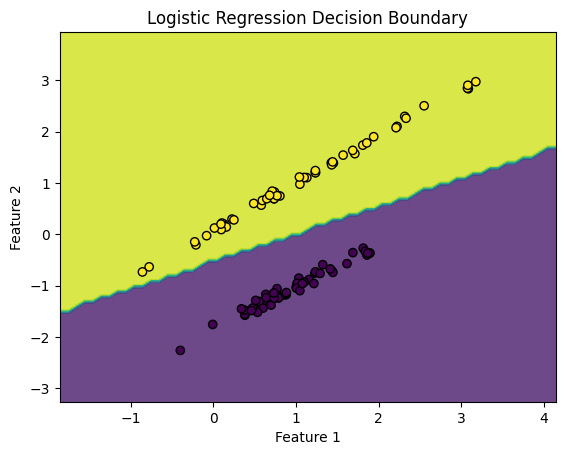

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Logistic regression is a linear model for classification
class LogisticRegression:
    # Let's initialize the parameteres of logistic regression
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None

    # The sigmoid function is used to map the output of the linear model into a probability between 0 and 1
    # The sigmoid function define as sigmoid(z) = 1 / (1 + exp(-z))
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    # Now we will implement the fit method to train the logistic regression model using gradient descent
    def fit(self, X, y):
        num_samples, num_features = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(num_features)
        self.bias = 0

        # Gradient descent using the cost function
        for _ in range(self.num_iterations):
            # Linear model
            linear_model = np.dot(X, self.weights) + self.bias

            # Apply sigmoid function to get predicted probabilities
            y_predicted = self._sigmoid(linear_model)

            # Compute gradients
            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / num_samples) * np.sum(y_predicted - y)

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    # Now we will implement the weights and bias from fit method to make predictions
    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(linear_model)

        # We have to convert the predicted probabilities into binary labels (0 or 1)
        y_predicted_labels = [1 if i > 0.5 else 0 for i in y_predicted]
        return np.array(y_predicted_labels)
    
    # We can visualize the decision boundary of the logistic regression model
    def plot_decision_boundary(self, X, y):
        x_min, x_max =  X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        Z = self.predict(np.array([xx.ravel(), yy.ravel()]).T)
        Z = Z.reshape(xx.shape)
        plt.contourf(xx, yy, Z, alpha=0.8)
        plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.title('Logistic Regression Decision Boundary')
        plt.show()

class __main__:
    # Let's try to use the logistic regression model on a simple dataset
    from sklearn.datasets import make_classification
    X, y = make_classification(n_samples=100, n_features=2, n_classes=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)

    model = LogisticRegression(learning_rate=0.1, num_iterations=1000)
    model.fit(X, y)
    predictions = model.predict(X)
    print("Predictions:", predictions)
    model.plot_decision_boundary(X, y)

